In [5]:
import scanpy as sc

import zs_perturbation

# Latent space observations

Here, we compute the latent space for a given disease (psoriasis):


In [2]:
adata = zs_perturbation.load_dataset("PSO")

/Users/quentinblampey/dev/zs_perturbation/zs_perturbation/io.py:23: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


First, we store the model embedding:


In [3]:
adata.obsm["z"] = zs_perturbation.encode(adata).numpy(force=True)

Encoding:   0%|          | 0/8 [00:00<?, ?it/s]

We run a UMAP:


In [6]:
sc.pp.neighbors(adata, use_rep="z")
sc.tl.umap(adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


And plot the results:


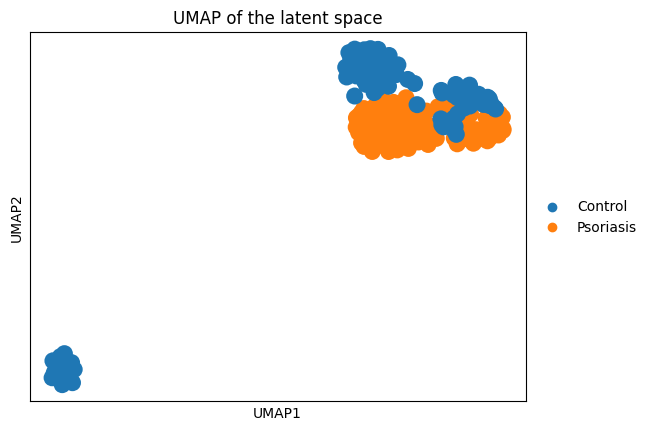

In [13]:
sc.pl.umap(adata, color="disease", title="UMAP of the latent space")

It seems one dataset has a strong difference with the other datasets:


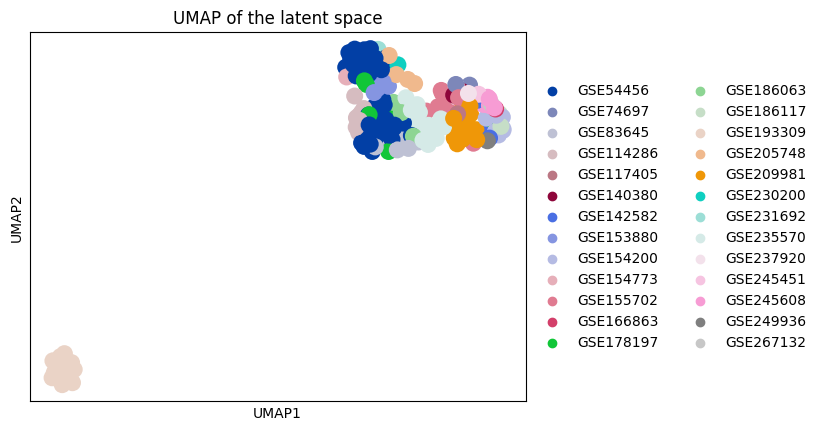

In [12]:
sc.pl.umap(adata, color="dataset_name", title="UMAP of the latent space")